<a href="https://colab.research.google.com/github/zyf-hitsz/PytorchLearning/blob/main/%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/%E7%8E%B0%E4%BB%A3%E5%8D%B7%E7%A7%AF%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C%E7%9A%84%E5%90%AF%E5%8F%91%E5%BC%8F%E6%A6%82%E5%BF%B5/HeuristicConcepts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

梳理一些用于设计深层神经网络的启发式概念，包括VGG、NiN、
、GoogLeNet和批量规范化。
##使用块的网络VGG
###VGG块
```
经典卷积神经网络的基本组成部分是下面的这个序列：

- 带填充以保持分辨率的卷积层；

- 非线性激活函数，如ReLU；

- 池化层。

```
而一个VGG块与之类似，由一系列卷积层组成，后面再加上用于空间下采样的最大池化层。在下面的代码中，我们定义了一个名为vgg_block的函数来实现一个VGG块。


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def vgg_block(num_convs, in_channels, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, out_channels,
                                kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        in_channels = out_channels
    layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
    return nn.Sequential(*layers)

该函数有三个参数，分别对应于卷积层的数量`num_convs`、输入通道的数量`in_channels`
和输出通道的数量`out_channels`.

###VGG网络
VGG网络可以分为两部分：第一部分主要由卷积层和汇聚层组成，第二部分由全连接层组成。
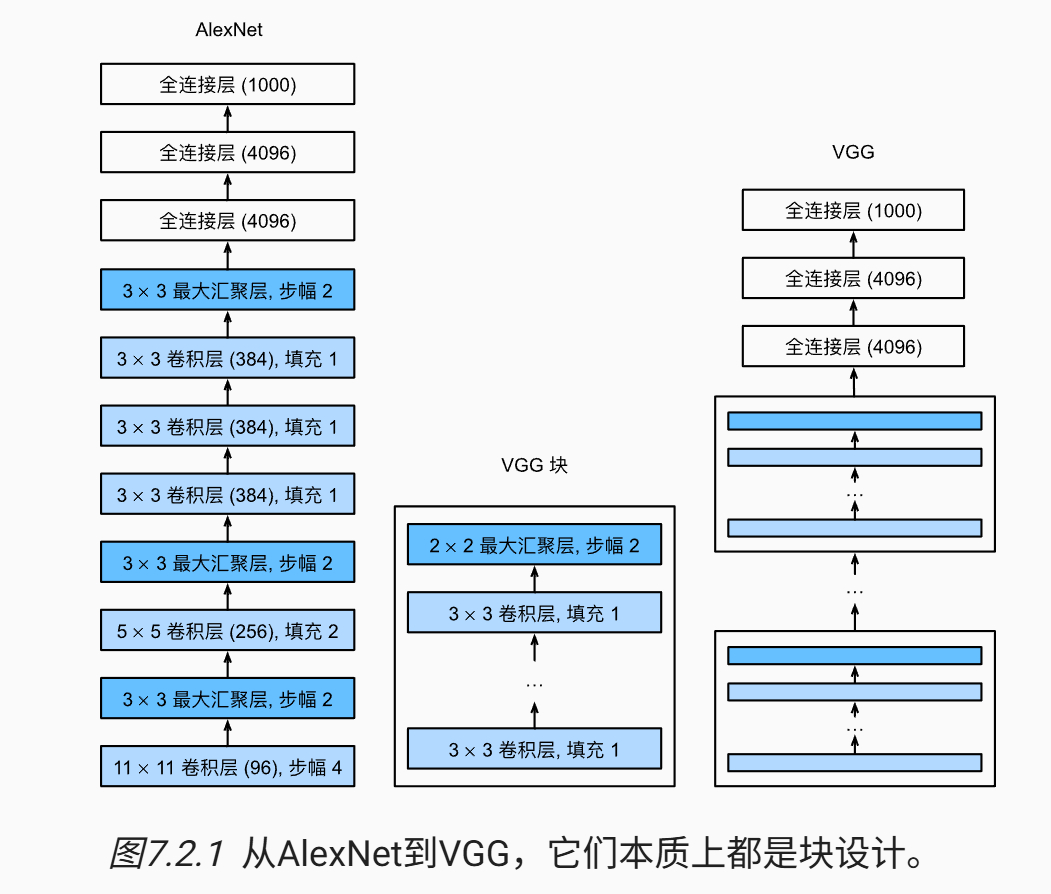

原始VGG网络有5个卷积块，其中前两个块各有一个卷积层，后三个块各包含两个卷积层。 第一个模块有64个输出通道，每个后续模块将输出通道数量翻倍，直到该数字达到512。由于该网络使用8个卷积层和3个全连接层，因此它通常被称为VGG-11。

下面的代码实现了VGG-11。可以通过在`conv_arch`上执行for循环来简单实现。

In [ ]:
conv_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))
def vgg(conv_arch):
    conv_blks = []
    in_channels = 1
    # 卷积层部分
    for (num_convs, out_channels) in conv_arch:
        conv_blks.append(vgg_block(num_convs, in_channels, out_channels))
        in_channels = out_channels

    return nn.Sequential(
        *conv_blks, nn.Flatten(),
        # 全连接层部分
        nn.Linear(out_channels * 7 * 7, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 10))

net = vgg(conv_arch)

接下来，我们将构建一个高度和宽度为224的单通道数据样本，以[**观察每个层输出的形状**]。

In [ ]:
X = torch.randn(size=(1, 1, 224, 224))
for blk in net:
    X = blk(X)
    print(blk.__class__.__name__,'output shape:\t',X.shape)

Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


In [ ]:
def load_data_fashion_mnist(batch_size, resize=224):
    """
    下载Fashion-MNIST并创建训练集和测试集的数据加载器。
    """
    transform = transforms.Compose([
        transforms.Resize((resize, resize)),
        transforms.ToTensor()
    ])

    train_dataset = datasets.FashionMNIST(
        root="../data",
        train=True,
        transform=transform,
        download=True
    )

    test_dataset = datasets.FashionMNIST(
        root="../data",
        train=False,
        transform=transform,
        download=True
    )

    train_iter = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    test_iter = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    return train_iter, test_iter


def try_gpu():
    """有GPU就使用GPU，否则使用CPU。"""
    if torch.cuda.is_available():
        return torch.device("cuda:0")

    return torch.device("cpu")


def accuracy(y_hat, y):
    """计算一个批次中预测正确的样本数量。"""
    predicted = y_hat.argmax(dim=1)
    correct = (predicted == y).sum()

    return correct.item()


def evaluate_accuracy_gpu(net, data_iter, device):
    """在测试集上计算分类准确率。"""
    net.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in data_iter:
            X = X.to(device)
            y = y.to(device)

            y_hat = net(X)

            correct += accuracy(y_hat, y)
            total += y.numel()

    return correct / total


def init_weights(module):
    """
    使用Xavier均匀初始化。
    """
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)


def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):


    # 在训练前重新初始化卷积层和全连接层的权重
    net.apply(init_weights)

    print(f"training on {device}")

    net.to(device)


    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss_function = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        net.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for X, y in train_iter:
            X = X.to(device)
            y = y.to(device)

            # 清除上一轮反向传播得到的梯度
            optimizer.zero_grad()

            # 前向传播
            y_hat = net(X)

            # 计算损失
            loss = loss_function(y_hat, y)

            # 反向传播
            loss.backward()

            # 更新参数
            optimizer.step()

            batch_size = y.size(0)

            total_loss += loss.item() * batch_size
            total_correct += accuracy(y_hat, y)
            total_samples += batch_size

        train_loss = total_loss / total_samples
        train_accuracy = total_correct / total_samples

        test_accuracy = evaluate_accuracy_gpu(
            net,
            test_iter,
            device
        )

        print(
            f"epoch {epoch + 1:2d}, "
            f"loss {train_loss:.4f}, "
            f"train acc {train_accuracy:.4f}, "
            f"test acc {test_accuracy:.4f}"
        )


def main():
    # 将每层通道数缩小到原来的1/4，降低计算量
    ratio = 4

    small_conv_arch = [
        (num_convs, out_channels // ratio)
        for num_convs, out_channels in conv_arch
    ]

    # 实际用于训练的是缩小后的VGG网络
    net = vgg(small_conv_arch)

    # 训练超参数
    lr = 0.05
    num_epochs = 10
    batch_size = 128

    train_iter, test_iter = load_data_fashion_mnist(
        batch_size=batch_size,
        resize=224
    )

    device = try_gpu()

    train_ch6(
        net,
        train_iter,
        test_iter,
        num_epochs,
        lr,
        device
    )


if __name__ == "__main__":
    main()

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.97MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.1MB/s]


training on cuda:0
epoch  1, loss 0.8786, train acc 0.6807, test acc 0.8472
epoch  2, loss 0.3918, train acc 0.8561, test acc 0.8683
epoch  3, loss 0.3214, train acc 0.8822, test acc 0.8853
epoch  4, loss 0.2814, train acc 0.8967, test acc 0.8963
epoch  5, loss 0.2563, train acc 0.9059, test acc 0.9064
epoch  6, loss 0.2313, train acc 0.9158, test acc 0.9061
epoch  7, loss 0.2151, train acc 0.9207, test acc 0.9067
epoch  8, loss 0.2003, train acc 0.9266, test acc 0.9205
epoch  9, loss 0.1861, train acc 0.9310, test acc 0.9183
epoch 10, loss 0.1739, train acc 0.9367, test acc 0.9184


VGG 没有提出特殊的优化器或复杂的训练算法，但提出了一种非常重要的网络架构设计原则：使用统一的小卷积核和重复卷积块，有规律地增加网络深度。加深深度，使用更多次的非线性激活，让网络可以学习更复杂的特性。

##网络中的网络NiN
LeNet、AlexNet和VGG都有一个共同的设计模式：通过一系列的卷积层与汇聚层来提取空间结构特征；然后通过全连接层对特征的表征进行处理。 AlexNet和VGG对LeNet的改进主要在于如何扩大和加深网络。 或者，我们想象在这个过程的早期使用全连接层，然而这样可能会完全放弃表征的空间结构。 网络中的网络（NiN）提供了一个非常简单的解决方案：在每个像素的通道上分别使用多层感知机。

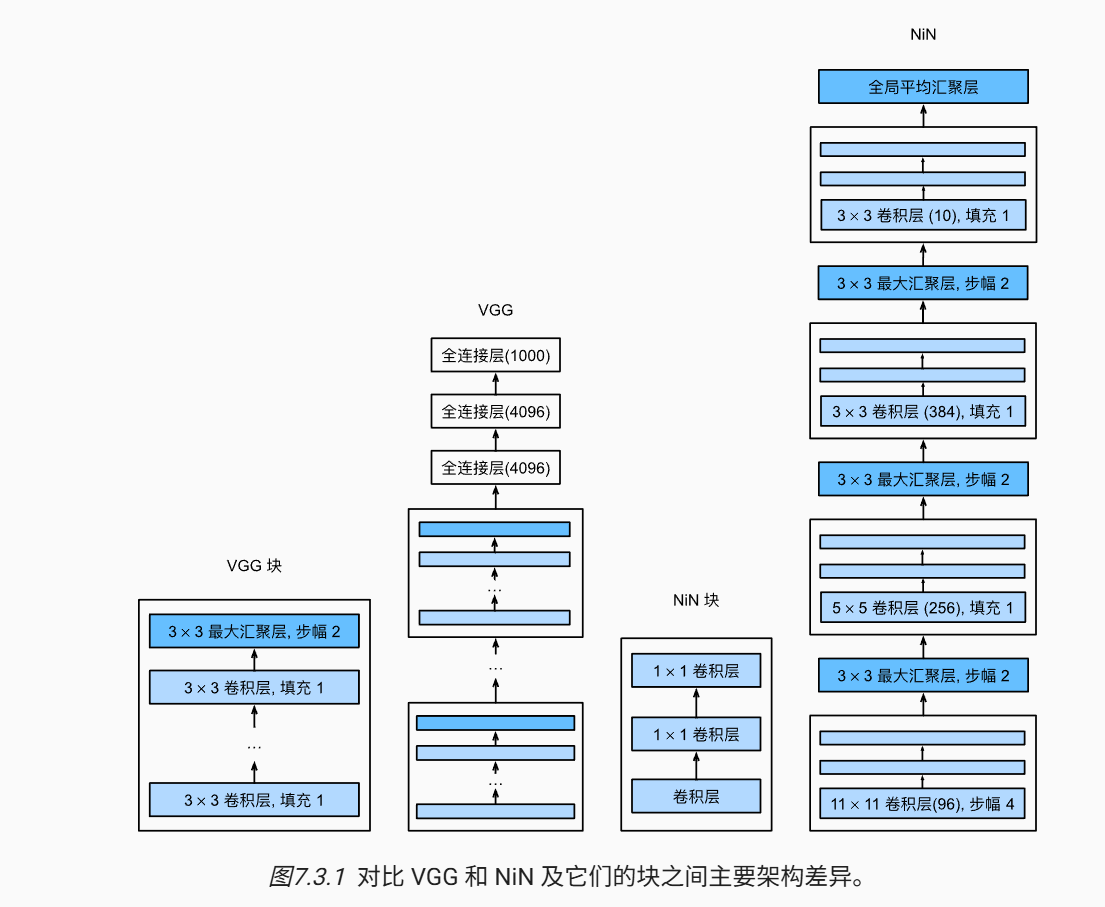

NiN块以一个普通卷积层开始，后面是两个 1×1 的卷积层。这两个 1×1 卷积层充当带有ReLU激活函数的逐像素全连接层。NiN和AlexNet之间的一个显著区别是NiN完全取消了全连接层。 相反，NiN使用一个NiN块，其输出通道数等于标签类别的数量。最后放一个全局平均汇聚层（global average pooling layer），生成一个对数几率 （logits）。NiN设计的一个优点是，它显著减少了模型所需参数的数量。然而，在实践中，这种设计有时会增加训练模型的时间。

Using device: cuda
layer 00 Sequential       -> (1, 96, 54, 54)
layer 01 MaxPool2d        -> (1, 96, 26, 26)
layer 02 Sequential       -> (1, 256, 26, 26)
layer 03 MaxPool2d        -> (1, 256, 12, 12)
layer 04 Sequential       -> (1, 384, 12, 12)
layer 05 MaxPool2d        -> (1, 384, 5, 5)
layer 06 Dropout          -> (1, 384, 5, 5)
layer 07 Sequential       -> (1, 10, 5, 5)
layer 08 AdaptiveAvgPool2d -> (1, 10, 1, 1)
layer 09 Flatten          -> (1, 10)


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 172kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.09MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.4MB/s]


Epoch 01/10 | loss 2.1219 | train acc 0.2107 | test acc 0.1955
Epoch 02/10 | loss 1.2559 | train acc 0.5286 | test acc 0.6901
Epoch 03/10 | loss 0.8052 | train acc 0.7013 | test acc 0.6896
Epoch 04/10 | loss 0.6447 | train acc 0.7616 | test acc 0.7893
Epoch 05/10 | loss 0.5378 | train acc 0.8035 | test acc 0.8209
Epoch 06/10 | loss 0.4654 | train acc 0.8300 | test acc 0.8421
Epoch 07/10 | loss 0.4277 | train acc 0.8434 | test acc 0.8445
Epoch 08/10 | loss 0.3979 | train acc 0.8548 | test acc 0.8415
Epoch 09/10 | loss 0.3754 | train acc 0.8610 | test acc 0.8627
Epoch 10/10 | loss 0.3552 | train acc 0.8706 | test acc 0.8675


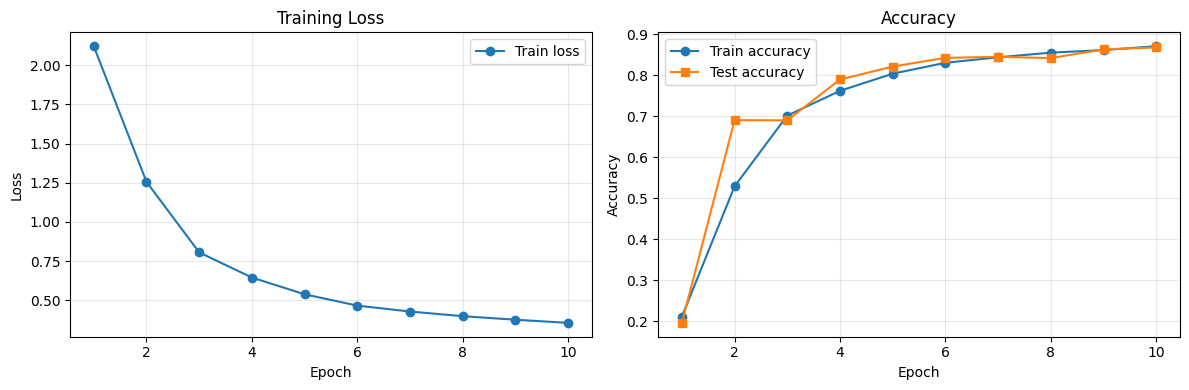

In [ ]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


def nin_block(in_channels, out_channels, kernel_size, stride, padding):
    """A NiN block: one spatial convolution followed by two 1 x 1 convolutions."""
    return nn.Sequential(
        nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        ),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(inplace=True),
    )


def build_nin():
    """Build NiN with exactly the channel and layer settings in the MXNet code."""
    return nn.Sequential(
        nin_block(1, 96, kernel_size=11, stride=4, padding=0),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nin_block(96, 256, kernel_size=5, stride=1, padding=2),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nin_block(256, 384, kernel_size=3, stride=1, padding=1),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Dropout(p=0.5),
        nin_block(384, 10, kernel_size=3, stride=1, padding=1),
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
    )


def init_weights(module):
    """Match the Xavier initialization used by d2l.train_ch6."""
    if isinstance(module, nn.Conv2d):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)


def show_output_shapes(model):
    """Print the output shape after every top-level layer."""
    x = torch.rand(1, 1, 224, 224)
    model.eval()
    with torch.no_grad():
        for index, layer in enumerate(model):
            x = layer(x)
            print(f"layer {index:02d} {layer.__class__.__name__:16s} -> {tuple(x.shape)}")


def load_fashion_mnist(batch_size):
    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
        ]
    )
    train_set = datasets.FashionMNIST(
        root="./data", train=True, transform=transform, download=True
    )
    test_set = datasets.FashionMNIST(
        root="./data", train=False, transform=transform, download=True
    )

    loader_options = {
        "batch_size": batch_size,
        "num_workers": 2,
        "pin_memory": torch.cuda.is_available(),
    }
    train_loader = DataLoader(train_set, shuffle=True, **loader_options)
    test_loader = DataLoader(test_set, shuffle=False, **loader_options)
    return train_loader, test_loader


@torch.no_grad()
def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
    return correct / total


def train(model, train_loader, test_loader, num_epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    history = {"loss": [], "train_acc": [], "test_acc": []}
    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        loss_sum = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            loss_sum += loss.item() * batch_size
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += batch_size

        epoch_loss = loss_sum / total
        train_acc = correct / total
        test_acc = evaluate_accuracy(model, test_loader, device)

        history["loss"].append(epoch_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"loss {epoch_loss:.4f} | "
            f"train acc {train_acc:.4f} | test acc {test_acc:.4f}"
        )

    return history


def plot_history(history):
    epochs = range(1, len(history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["loss"], marker="o", label="Train loss")
    axes[0].set(xlabel="Epoch", ylabel="Loss", title="Training Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], marker="o", label="Train accuracy")
    axes[1].plot(epochs, history["test_acc"], marker="s", label="Test accuracy")
    axes[1].set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def main():
    # Keep the original hyperparameters unchanged.
    learning_rate = 0.1
    num_epochs = 10
    batch_size = 128

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model = build_nin()
    model.apply(init_weights)
    show_output_shapes(model)

    train_loader, test_loader = load_fashion_mnist(batch_size)
    history = train(
        model,
        train_loader,
        test_loader,
        num_epochs,
        learning_rate,
        device,
    )
    plot_history(history)


if __name__ == "__main__":
    main()


NiN的核心特点，是用更强的“微型网络”替代传统卷积层，并用全局平均池化完成分类。
它大量使用1×1的微型卷积层，相当于在每个像素的位置应用一个共享的多层感知机，增强非线性表达能力。NiN的参数不太大，但是由于大量卷积，计算量比较大，训练时长也会比较长。

##含并行连结的网络GoogLeNet
GoogLeNet吸收了NiN中串联网络的思想，并在此基础上做了改进。它重点解决了什么样大小的卷积核最合适的问题。
###Inception块
在GoogLeNet中，基本的卷积块被称为Inception块。Inception块由四条并行路径组成，前三条路径使用窗口大小为 1×1 、 3×3 和 5×5 的卷积层，从不同空间大小中提取信息。 中间的两条路径在输入上执行 1×1 卷积，以减少通道数，从而降低模型的复杂性。 第四条路径使用 3×3 最大汇聚层，然后使用 1×1 卷积层来改变通道数。 这四条路径都使用合适的填充来使输入与输出的高和宽一致，最后我们将每条线路的输出在通道维度上连结，并构成Inception块的输出。在Inception块中，通常调整的超参数是每层输出通道数。
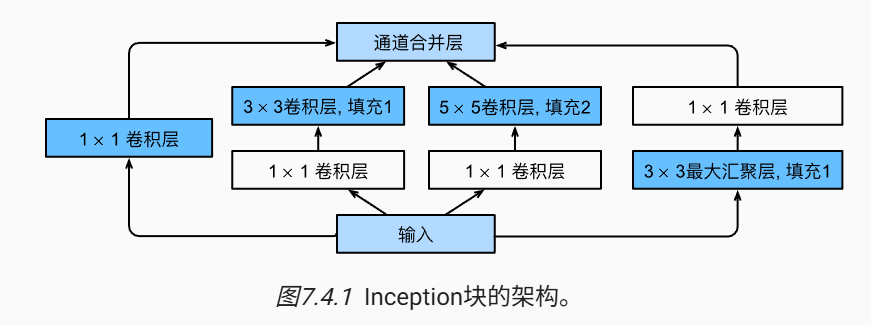

不同的线路上的卷积块尺度不同，意味着不同的支路可以学习不同范围的图像细节，并在最后综合在一起。GoogLeNet模型的计算复杂，而且不如VGG那样便于修改通道数。

b1       (Sequential) output shape:	torch.Size([1, 64, 24, 24])
b2       (Sequential) output shape:	torch.Size([1, 192, 12, 12])
b3       (Sequential) output shape:	torch.Size([1, 480, 6, 6])
b4       (Sequential) output shape:	torch.Size([1, 832, 3, 3])
b5       (Sequential) output shape:	torch.Size([1, 1024])
Linear   (Linear) output shape:	torch.Size([1, 10])

训练设备：cuda
epoch  1/10, train loss 1.9632, train acc 0.2600, test loss 0.9584, test acc 0.6083
epoch  2/10, train loss 0.7858, train acc 0.6925, test loss 0.5815, test acc 0.7838
epoch  3/10, train loss 0.4962, train acc 0.8133, test loss 0.5413, test acc 0.7984
epoch  4/10, train loss 0.3941, train acc 0.8526, test loss 0.5549, test acc 0.7777
epoch  5/10, train loss 0.3464, train acc 0.8698, test loss 0.3678, test acc 0.8551
epoch  6/10, train loss 0.3140, train acc 0.8821, test loss 0.3427, test acc 0.8709
epoch  7/10, train loss 0.2916, train acc 0.8884, test loss 0.2974, test acc 0.8871
epoch  8/10, train loss 0.2728, trai

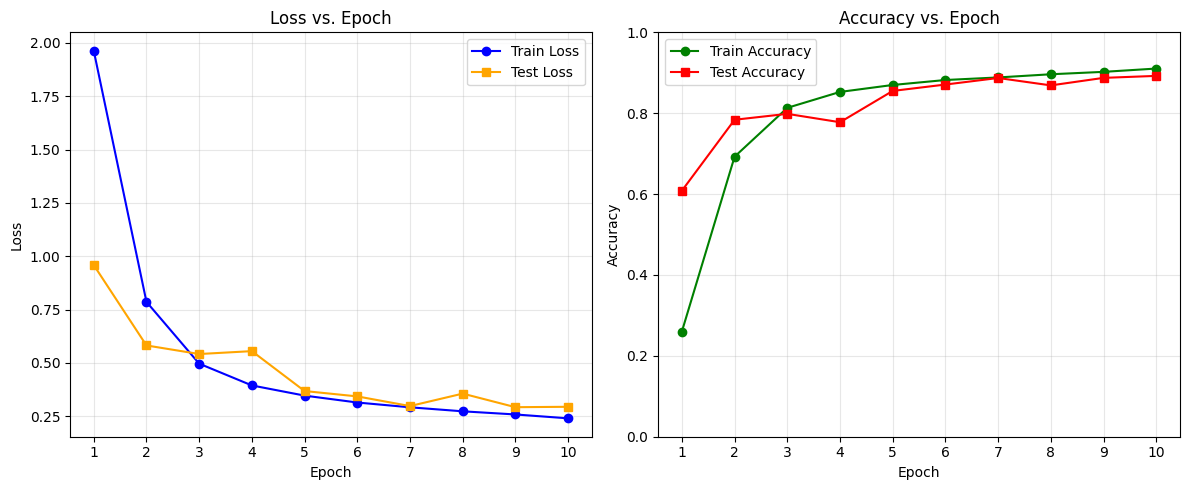

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


# ============================================================
# 1. Inception模块
# ============================================================
class Inception(nn.Module):
    """
    GooLeNet的基本组成模块。

    输入特征图会同时经过4条并行路径：
    路径1：1×1卷积
    路径2：1×1卷积 -> 3×3卷积
    路径3：1×1卷积 -> 5×5卷积
    路径4：3×3最大池化 -> 1×1卷积

    4条路径的结果最后在通道维度上拼接。

    参数：
        in_channels：输入特征图的通道数
        c1：路径1的输出通道数
        c2：路径2中两个卷积层的输出通道数
        c3：路径3中两个卷积层的输出通道数
        c4：路径4中1×1卷积层的输出通道数
    """

    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)

        # 路径1：单个1×1卷积
        self.p1_1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=c1,
            kernel_size=1
        )

        # 路径2：1×1卷积后接3×3卷积
        # 1×1卷积用于调整通道数，降低3×3卷积的计算量
        self.p2_1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=c2[0],
            kernel_size=1
        )
        self.p2_2 = nn.Conv2d(
            in_channels=c2[0],
            out_channels=c2[1],
            kernel_size=3,
            padding=1
        )

        # 路径3：1×1卷积后接5×5卷积
        # padding=2保证卷积前后特征图的高和宽不变
        self.p3_1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=c3[0],
            kernel_size=1
        )
        self.p3_2 = nn.Conv2d(
            in_channels=c3[0],
            out_channels=c3[1],
            kernel_size=5,
            padding=2
        )

        # 路径4：3×3最大池化后接1×1卷积
        # stride=1和padding=1保证池化前后尺寸不变
        self.p4_1 = nn.MaxPool2d(
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.p4_2 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=c4,
            kernel_size=1
        )

    def forward(self, x):
        # 路径1
        p1 = F.relu(self.p1_1(x))

        # 路径2
        p2 = F.relu(self.p2_1(x))
        p2 = F.relu(self.p2_2(p2))

        # 路径3
        p3 = F.relu(self.p3_1(x))
        p3 = F.relu(self.p3_2(p3))

        # 路径4
        p4 = self.p4_1(x)
        p4 = F.relu(self.p4_2(p4))

        # 沿通道维度拼接4条路径的结果
        return torch.cat((p1, p2, p3, p4), dim=1)


# ============================================================
# 2. GooLeNet第一部分
#
# 输入形状：(batch_size, 1, 96, 96)
# 经过7×7卷积后：(batch_size, 64, 48, 48)
# 经过最大池化后：(batch_size, 64, 24, 24)
# ============================================================
b1 = nn.Sequential(
    nn.Conv2d(
        in_channels=1,
        out_channels=64,
        kernel_size=7,
        stride=2,
        padding=3
    ),
    nn.ReLU(),
    nn.MaxPool2d(
        kernel_size=3,
        stride=2,
        padding=1
    )
)


# ============================================================
# 3. GooLeNet第二部分
#
# 1×1卷积保持64个通道；
# 3×3卷积把通道数增加到192；
# 最大池化将特征图的高和宽减半。
# ============================================================
b2 = nn.Sequential(
    nn.Conv2d(
        in_channels=64,
        out_channels=64,
        kernel_size=1
    ),
    nn.ReLU(),

    nn.Conv2d(
        in_channels=64,
        out_channels=192,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    nn.MaxPool2d(
        kernel_size=3,
        stride=2,
        padding=1
    )
)


# ============================================================
# 4. GooLeNet第三部分
#
# 第一个Inception输出通道数：
# 64 + 128 + 32 + 32 = 256
#
# 第二个Inception输出通道数：
# 128 + 192 + 96 + 64 = 480
# ============================================================
b3 = nn.Sequential(
    Inception(
        in_channels=192,
        c1=64,
        c2=(96, 128),
        c3=(16, 32),
        c4=32
    ),

    Inception(
        in_channels=256,
        c1=128,
        c2=(128, 192),
        c3=(32, 96),
        c4=64
    ),

    nn.MaxPool2d(
        kernel_size=3,
        stride=2,
        padding=1
    )
)


# ============================================================
# 5. GooLeNet第四部分
#
# 包含5个Inception模块。
# 各模块通道数变化：
# 480 -> 512 -> 512 -> 512 -> 528 -> 832
# ============================================================
b4 = nn.Sequential(
    Inception(
        in_channels=480,
        c1=192,
        c2=(96, 208),
        c3=(16, 48),
        c4=64
    ),

    Inception(
        in_channels=512,
        c1=160,
        c2=(112, 224),
        c3=(24, 64),
        c4=64
    ),

    Inception(
        in_channels=512,
        c1=128,
        c2=(128, 256),
        c3=(24, 64),
        c4=64
    ),

    Inception(
        in_channels=512,
        c1=112,
        c2=(144, 288),
        c3=(32, 64),
        c4=64
    ),

    Inception(
        in_channels=528,
        c1=256,
        c2=(160, 320),
        c3=(32, 128),
        c4=128
    ),

    nn.MaxPool2d(
        kernel_size=3,
        stride=2,
        padding=1
    )
)


# ============================================================
# 6. GooLeNet第五部分
#
# 两个Inception模块的输出通道数分别为832和1024。
#
# AdaptiveAvgPool2d((1, 1))：
# 将每个通道的特征图压缩成一个数，相当于全局平均池化。
#
# Flatten：
# 将(batch_size, 1024, 1, 1)转换成(batch_size, 1024)。
# ============================================================
b5 = nn.Sequential(
    Inception(
        in_channels=832,
        c1=256,
        c2=(160, 320),
        c3=(32, 128),
        c4=128
    ),

    Inception(
        in_channels=832,
        c1=384,
        c2=(192, 384),
        c3=(48, 128),
        c4=128
    ),

    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten()
)


# ============================================================
# 7. 完整GooLeNet
#
# 最后的全连接层把1024维特征转换成10个类别的预测分数。
# 保持原代码的网络架构和参数不变。
# ============================================================
net = nn.Sequential(
    b1,
    b2,
    b3,
    b4,
    b5,
    nn.Linear(1024, 10)
)


# ============================================================
# 8. 查看每一部分的输出形状
# ============================================================
def print_output_shapes(model):
    x = torch.rand(size=(1, 1, 96, 96))

    layer_names = [
        "b1",
        "b2",
        "b3",
        "b4",
        "b5",
        "Linear"
    ]

    model.eval()

    with torch.no_grad():
        for name, layer in zip(layer_names, model):
            x = layer(x)
            print(
                f"{name:8s} "
                f"({layer.__class__.__name__}) "
                f"output shape:\t{x.shape}"
            )


# ============================================================
# 9. 使用PyTorch通用代码加载Fashion-MNIST
#
# 替代：
# d2l.load_data_fashion_mnist(batch_size, resize=96)
# ============================================================
def load_fashion_mnist(batch_size, resize=96):
    # 原始Fashion-MNIST图像是28×28。
    # Resize将其缩放到GooLeNet使用的96×96。
    # ToTensor将图像转换成形状为(C, H, W)的浮点Tensor，
    # 同时把像素值缩放到[0, 1]。
    transform = transforms.Compose([
        transforms.Resize((resize, resize)),
        transforms.ToTensor()
    ])

    # 训练集，共60000张图像
    train_dataset = datasets.FashionMNIST(
        root="./data",
        train=True,
        transform=transform,
        download=True
    )

    # 测试集，共10000张图像
    test_dataset = datasets.FashionMNIST(
        root="./data",
        train=False,
        transform=transform,
        download=True
    )

    # 训练集需要打乱样本顺序
    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    # 测试集不需要打乱
    test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, test_loader


# ============================================================
# 10. Xavier参数初始化
#
# d2l.train_ch6内部会对卷积层和全连接层执行Xavier初始化，
# 因此这里使用PyTorch官方函数完成相同操作。
# ============================================================
def init_weights(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)

        if module.bias is not None:
            nn.init.zeros_(module.bias)


# ============================================================
# 11. 计算测试集的loss和accuracy
# ============================================================
def evaluate_model(model, data_loader, loss_function, device):
    # 切换到验证模式
    model.eval()

    loss_sum = 0.0
    correct_sum = 0
    sample_sum = 0

    # 测试阶段不计算梯度
    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # 前向传播，得到10个类别的预测分数
            outputs = model(features)

            # 计算当前批次的交叉熵损失
            loss = loss_function(outputs, labels)

            current_batch_size = labels.size(0)

            # loss.item()是当前批次的平均损失
            loss_sum += loss.item() * current_batch_size

            # 选择预测分数最大的类别
            predictions = outputs.argmax(dim=1)

            correct_sum += (
                predictions == labels
            ).sum().item()

            sample_sum += current_batch_size

    average_loss = loss_sum / sample_sum
    accuracy = correct_sum / sample_sum

    return average_loss, accuracy


# ============================================================
# 12. 使用PyTorch通用训练循环
#
# 替代：
# d2l.train_ch6(...)
#
# 每个epoch记录：
# 训练集loss、测试集loss、训练集accuracy、测试集accuracy。
# ============================================================
def train_model(
    model,
    train_loader,
    test_loader,
    num_epochs,
    learning_rate,
    device
):
    # 与d2l.train_ch6保持一致，训练前执行Xavier初始化
    model.apply(init_weights)

    # 将网络移动到GPU或CPU
    model.to(device)

    # 多分类任务使用交叉熵损失
    # CrossEntropyLoss内部已经包含Softmax，
    # 因此网络最后不需要额外添加Softmax层
    loss_function = nn.CrossEntropyLoss()

    # 保持原代码优化器和学习率不变
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate
    )

    # 保存每个epoch的指标，供后面画图
    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": []
    }

    for epoch in range(num_epochs):
        # 切换到训练模式
        model.train()

        train_loss_sum = 0.0
        train_correct_sum = 0
        train_sample_sum = 0

        for features, labels in train_loader:
            features = features.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # 清除上一个批次保存的梯度
            optimizer.zero_grad()

            # 前向传播
            outputs = model(features)

            # 计算损失
            loss = loss_function(outputs, labels)

            # 反向传播，计算梯度
            loss.backward()

            # 使用梯度更新网络参数
            optimizer.step()

            current_batch_size = labels.size(0)

            # 累加损失
            train_loss_sum += loss.item() * current_batch_size

            # 计算当前批次预测正确的样本数
            predictions = outputs.argmax(dim=1)

            train_correct_sum += (
                predictions == labels
            ).sum().item()

            train_sample_sum += current_batch_size

        # 当前epoch的训练集平均损失和准确率
        train_loss = train_loss_sum / train_sample_sum
        train_acc = train_correct_sum / train_sample_sum

        # 当前epoch的测试集平均损失和准确率
        test_loss, test_acc = evaluate_model(
            model=model,
            data_loader=test_loader,
            loss_function=loss_function,
            device=device
        )

        # 保存当前epoch的结果
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        print(
            f"epoch {epoch + 1:2d}/{num_epochs}, "
            f"train loss {train_loss:.4f}, "
            f"train acc {train_acc:.4f}, "
            f"test loss {test_loss:.4f}, "
            f"test acc {test_acc:.4f}"
        )

    return history


# ============================================================
# 13. 绘制loss和accuracy随epoch变化的曲线
# ============================================================
def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # 左图：训练集和测试集损失
    plt.subplot(1, 2, 1)

    plt.plot(
        epochs,
        history["train_loss"],
        color="blue",
        marker="o",
        label="Train Loss"
    )

    plt.plot(
        epochs,
        history["test_loss"],
        color="orange",
        marker="s",
        label="Test Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs. Epoch")
    plt.xticks(list(epochs))
    plt.grid(alpha=0.3)
    plt.legend()

    # 右图：训练集和测试集准确率
    plt.subplot(1, 2, 2)

    plt.plot(
        epochs,
        history["train_acc"],
        color="green",
        marker="o",
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        history["test_acc"],
        color="red",
        marker="s",
        label="Test Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs. Epoch")
    plt.xticks(list(epochs))
    plt.ylim(0.0, 1.0)
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 14. 主程序
# ============================================================
if __name__ == "__main__":
    # 输出网络各部分的形状
    print_output_shapes(net)

    # 保持原代码中的超参数不变
    lr = 0.1
    num_epochs = 10
    batch_size = 128

    # 使用PyTorch官方工具加载数据
    train_iter, test_iter = load_fashion_mnist(
        batch_size=batch_size,
        resize=96
    )

    # 自动选择GPU；没有可用GPU时使用CPU
    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print(f"\n训练设备：{device}")

    # 训练网络并返回每个epoch的指标
    history = train_model(
        model=net,
        train_loader=train_iter,
        test_loader=test_iter,
        num_epochs=num_epochs,
        learning_rate=lr,
        device=device
    )

    # 绘制loss和accuracy曲线
    plot_training_curves(history)

##批量规范化Batch Normalization
训练深层神经网络是十分困难的，特别是在较短的时间内使他们收敛。批量规范化（batch normalization）是一种流行且有效的技术，可以持续加速深层网络的收敛速度。

### 训练深层神经网络的挑战
```
- 数据预处理的方式通常会对最终结果产生巨大影响
- 中间层中的变量可能具有更广的变化范围
- 更深层的网络很复杂，容易过拟合
```
批量规范化应用于单个可选层（也可以应用到所有层），其原理如下：在每次训练迭代中，我们首先规范化输入，即通过减去其均值并除以其标准差，其中两者均基于当前小批量处理。
接下来，我们应用比例系数和比例偏移。
正是由于这个基于*批量*统计的*标准化*，才有了*批量规范化*的名称。

请注意，如果我们尝试使用大小为1的小批量应用批量规范化，我们将无法学到任何东西。
这是因为在减去均值之后，每个隐藏单元将为0。
所以，只有使用足够大的小批量，批量规范化这种方法才是有效且稳定的。
请注意，在应用批量规范化时，批量大小的选择可能比没有批量规范化时更重要。

从形式上来说，用$\mathbf{x} \in \mathcal{B}$表示一个来自小批量$\mathcal{B}$的输入，批量规范化$\mathrm{BN}$根据以下表达式转换$\mathbf{x}$：

$$\mathrm{BN}(\mathbf{x}) = \boldsymbol{\gamma} \odot \frac{\mathbf{x} - \hat{\boldsymbol{\mu}}_\mathcal{B}}{\hat{\boldsymbol{\sigma}}_\mathcal{B}} + \boldsymbol{\beta}.$$

$\hat{\boldsymbol{\mu}}_\mathcal{B}$是小批量$\mathcal{B}$的样本均值，$\hat{\boldsymbol{\sigma}}_\mathcal{B}$是小批量$\mathcal{B}$的样本标准差。
应用标准化后，生成的小批量的平均值为0和单位方差为1。
由于单位方差（与其他一些魔法数）是一个主观的选择，因此我们通常包含
*拉伸参数*（scale）$\boldsymbol{\gamma}$和*偏移参数*（shift）$\boldsymbol{\beta}$，它们的形状与$\mathbf{x}$相同。
请注意，$\boldsymbol{\gamma}$和$\boldsymbol{\beta}$是需要与其他模型参数一起学习的参数。

由于在训练过程中，中间层的变化幅度不能过于剧烈，而批量规范化将每一层主动居中，并将它们重新调整为给定的平均值和大小（通过$\hat{\boldsymbol{\mu}}_\mathcal{B}$和${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$）。

从形式上来看，我们计算出 :$\hat{\boldsymbol{\mu}}_\mathcal{B}$和${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$，如下所示：

$$\begin{aligned} \hat{\boldsymbol{\mu}}_\mathcal{B} &= \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} \mathbf{x},\\
\hat{\boldsymbol{\sigma}}_\mathcal{B}^2 &= \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} (\mathbf{x} - \hat{\boldsymbol{\mu}}_{\mathcal{B}})^2 + \epsilon.\end{aligned}$$

请注意，我们在方差估计值中添加一个小的常量$\epsilon > 0$，以确保我们永远不会尝试除以零，即使在经验方差估计值可能消失的情况下也是如此。估计值$\hat{\boldsymbol{\mu}}_\mathcal{B}$和${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$通过使用平均值和方差的噪声（noise）估计来抵消缩放问题。
乍看起来，这种噪声是一个问题，而事实上它是有益的。

事实证明，这是深度学习中一个反复出现的主题。
由于尚未在理论上明确的原因，优化中的各种噪声源通常会导致更快的训练和较少的过拟合：这种变化似乎是正则化的一种形式。
在一些初步研究中，将批量规范化的性质与贝叶斯先验相关联。
这些理论揭示了为什么批量规范化最适应$50 \sim 100$范围中的中等批量大小的难题。

另外，批量规范化层在”训练模式“（通过小批量统计数据规范化）和“预测模式”（通过数据集统计规范化）中的功能不同。
在训练过程中，我们无法得知使用整个数据集来估计平均值和方差，所以只能根据每个小批次的平均值和方差不断训练模型。
而在预测模式下，可以根据整个数据集精确计算批量规范化所需的平均值和方差。

现在，我们了解一下批量规范化在实践中是如何工作的。

## 批量规范化层

回想一下，批量规范化和其他层之间的一个关键区别是，由于批量规范化在完整的小批量上运行，因此我们不能像以前在引入其他层时那样忽略批量大小。
我们在下面讨论这两种情况：全连接层和卷积层，他们的批量规范化实现略有不同。

### 全连接层

通常，我们将批量规范化层置于全连接层中的仿射变换和激活函数之间。
设全连接层的输入为x，权重参数和偏置参数分别为$\mathbf{W}$和$\mathbf{b}$，激活函数为$\phi$，批量规范化的运算符为$\mathrm{BN}$。
那么，使用批量规范化的全连接层的输出的计算详情如下：

$$\mathbf{h} = \phi(\mathrm{BN}(\mathbf{W}\mathbf{x} + \mathbf{b}) ).$$

回想一下，均值和方差是在应用变换的"相同"小批量上计算的。

### 卷积层

同样，对于卷积层，我们可以在卷积层之后和非线性激活函数之前应用批量规范化。
当卷积有多个输出通道时，我们需要对这些通道的“每个”输出执行批量规范化，每个通道都有自己的拉伸（scale）和偏移（shift）参数，这两个参数都是标量。
假设我们的小批量包含$m$个样本，并且对于每个通道，卷积的输出具有高度$p$和宽度$q$。
那么对于卷积层，我们在每个输出通道的$m \cdot p \cdot q$个元素上同时执行每个批量规范化。
因此，在计算平均值和方差时，我们会收集所有空间位置的值，然后在给定通道内应用相同的均值和方差，以便在每个空间位置对值进行规范化。

### 预测过程中的批量规范化

正如我们前面提到的，批量规范化在训练模式和预测模式下的行为通常不同。
首先，将训练好的模型用于预测时，我们不再需要样本均值中的噪声以及在微批次上估计每个小批次产生的样本方差了。
其次，例如，我们可能需要使用我们的模型对逐个样本进行预测。
一种常用的方法是通过移动平均估算整个训练数据集的样本均值和方差，并在预测时使用它们得到确定的输出。
可见，和暂退法一样，批量规范化层在训练模式和预测模式下的计算结果也是不一样的。

这一部分内容实际上在BatchNorm层这一节里已经梳理过，这里重新提及，是将这一概念定性为优化模型训练效果的操作。